<a href="https://colab.research.google.com/github/pg-2209/first-project/blob/main/prasanjeetgoswamiweek5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

Step 2: Load Text Corpus

In [2]:
corpus = '''
Artificial intelligence is changing the way people work and communicate.
Machine learning enables computers to learn from data without explicit programming.
Deep learning uses multiple neural network layers to solve complex problems.
Artificial neural networks are inspired by the structure of the human brain.
Large datasets help machine learning models achieve better accuracy.
Data preprocessing improves the quality of training data.
Feature engineering helps algorithms identify useful patterns.
Training a model requires high quality data and sufficient computational power.
A well trained model can make accurate predictions on unseen data.
Natural language processing allows computers to understand human language.
Text classification is a common application of natural language processing.
Sentiment analysis identifies positive and negative opinions in text.
Language models predict the next word based on previous words.
Text generation creates meaningful sentences using learned language patterns.
Recurrent neural networks process sequential information one step at a time.
Simple recurrent neural networks struggle with long term dependencies.
Long short term memory networks solve the vanishing gradient problem.
Gated recurrent units provide efficient learning with fewer parameters.
Embedding layers convert words into dense numerical vectors.
Tokenization transforms text into sequences of numerical tokens.
Padding ensures that all input sequences have equal length.
Optimization algorithms improve model performance during training.
The Adam optimizer is widely used in deep learning applications.
Loss functions measure how well the model performs during training.
Each training epoch updates the network weights to reduce prediction errors.
Validation data helps evaluate model performance on unseen examples.
Overfitting occurs when a model memorizes training data instead of learning patterns.
Regularization techniques improve the ability of models to generalize.
Dropout layers randomly deactivate neurons during training to reduce overfitting.
Early stopping prevents unnecessary training after performance stops improving.
Sequence models are useful for language translation and speech recognition.
Chatbots use natural language processing to interact with users.
Virtual assistants understand spoken commands using deep learning.
Recommendation systems suggest products based on customer preferences.
Image recognition systems identify objects using convolutional neural networks.
Autonomous vehicles use artificial intelligence to make driving decisions.
Healthcare applications use machine learning to assist medical diagnosis.
Financial institutions use artificial intelligence to detect fraudulent transactions.
Educational platforms use intelligent systems to personalize learning experiences.
Researchers continue to develop more powerful and efficient deep learning models.
Artificial intelligence is expected to transform many industries in the future.
'''

Step 3: Tokenization and Sequence Creation

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

input_sequences = []

for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Vocabulary Size: 237
Input Shape: (349, 11)
Output Shape: (349,)


Step 4:Vanilla RNN Model


In [5]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

print("Vanilla RNN Training Completed")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0029 - loss: 5.4728    
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0401 - loss: 5.4132 
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0430 - loss: 5.3152 
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0229 - loss: 5.2077
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0315 - loss: 5.1142 
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0372 - loss: 5.0405 
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0487 - loss: 4.9717 
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0602 - loss: 4.9101 
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0688 - loss: 4.8376 
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0802 - loss: 4.7509 
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1117 - loss: 4.6556 
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy

Step 5: LSTM Model

In [6]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

print("LSTM Training Completed")

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0172 - loss: 5.4677
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0372 - loss: 5.4519
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0372 - loss: 5.4023
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0372 - loss: 5.2423
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0372 - loss: 5.1624
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0372 - loss: 5.1210
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0372 - loss: 5.0967
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0372 - loss: 5.0763
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0372 - loss: 5.0566
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0372 - loss: 5.0317
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0372 - loss: 5.0070
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accura

Step 6: GRU Model

In [7]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

print("GRU Training Completed")

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0057 - loss: 5.4673
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0516 - loss: 5.4513
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0430 - loss: 5.4256
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0287 - loss: 5.2998
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0172 - loss: 5.1993
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0372 - loss: 5.1169
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0372 - loss: 5.0769
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0372 - loss: 5.0566
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0372 - loss: 5.0250
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0372 - loss: 4.9926
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0401 - loss: 4.9474
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Step 7: Compare Training Loss

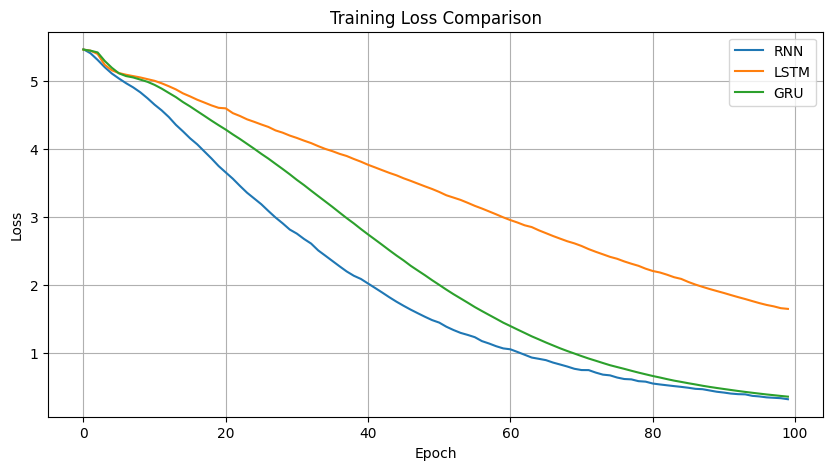

In [8]:
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['loss'], label='RNN')

plt.plot(lstm_history.history['loss'], label='LSTM')

plt.plot(gru_history.history['loss'], label='GRU')

plt.title("Training Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

Step 8: compare training Accuracy

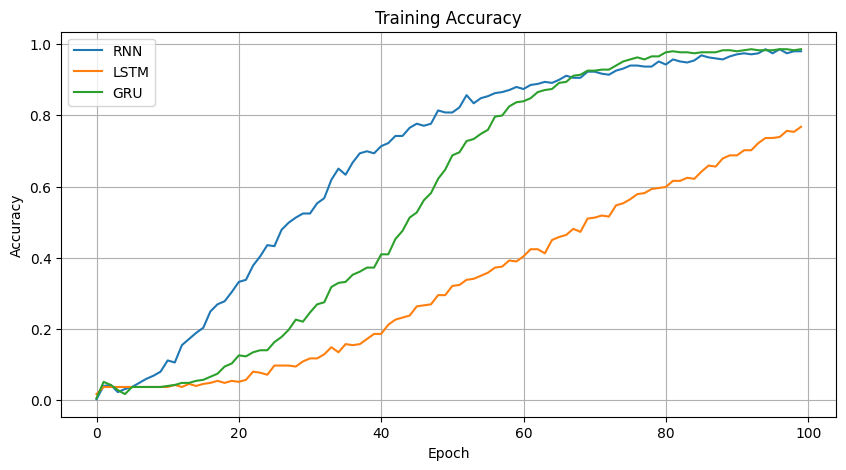

In [11]:
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['accuracy'], label="RNN")

plt.plot(lstm_history.history['accuracy'], label="LSTM")

plt.plot(gru_history.history['accuracy'], label="GRU")

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

Step 8:Text Generation Function


In [9]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

Step 9: Generate Text

In [10]:
print("Generated Text using RNN")
print(generate_text(rnn_model, "artificial intelligence", 10))

print()

print("Generated Text using LSTM")
print(generate_text(lstm_model, "artificial intelligence", 10))

print()

print("Generated Text using GRU")
print(generate_text(gru_model, "artificial intelligence", 10))

Generated Text using RNN
artificial intelligence is expected to transform many industries in the future personalize

Generated Text using LSTM
artificial intelligence is changing the way people work and communicate computational programming

Generated Text using GRU
artificial intelligence is changing the way people work and communicate communicate problem


In [12]:
print("RNN")
print(generate_text(rnn_model, "deep learning"))

print()

print("LSTM")
print(generate_text(lstm_model, "deep learning"))

print()

print("GRU")
print(generate_text(gru_model, "deep learning"))

RNN
deep learning uses multiple neural network layers to solve complex problems that

LSTM
deep learning learning to spoken commands using deep learning at a time

GRU
deep learning uses multiple neural network layers to solve complex problems problem


In [15]:
# Evaluate Vanilla RNN
rnn_loss, rnn_accuracy = rnn_model.evaluate(X, y, verbose=0)

# Evaluate LSTM
lstm_loss, lstm_accuracy = lstm_model.evaluate(X, y, verbose=0)

# Evaluate GRU
gru_loss, gru_accuracy = gru_model.evaluate(X, y, verbose=0)

print("===== Model Evaluation =====")
print(f"RNN  - Loss: {rnn_loss:.4f}, Accuracy: {rnn_accuracy:.4f}")
print(f"LSTM - Loss: {lstm_loss:.4f}, Accuracy: {lstm_accuracy:.4f}")
print(f"GRU  - Loss: {gru_loss:.4f}, Accuracy: {gru_accuracy:.4f}")

===== Model Evaluation =====
RNN  - Loss: 0.3015, Accuracy: 0.9914
LSTM - Loss: 1.5932, Accuracy: 0.7794
GRU  - Loss: 0.3389, Accuracy: 0.9857
